### GMM model draft

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [40]:
# Load the merged dataset
df = pd.read_csv("Filtered dataset/iSUPER_Weather_Underground_merged_2025.csv")

# Parse timestamp if needed
#df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)

display(df.head())
print(df["Dew/Temp fog?"].value_counts())
df["RH fog?"].value_counts()


,timestamp_utc,rh_sensor,temp_sensor,pm1,pm25,pm10,Temperature_C,Dew_Point_C,Humidity_%,Speed_kmh,Pressure_hPa,Precip_Rate_mm,Precip_Accum_mm,Wind,Dew/Temp fog?,RH fog?
0,2023-07-10 00:15:00+00:00,82.54,23.2,2.63,3.11,7.98,21.11,19.56,91.0,10.46,1011.18,0.0,0.0,East,1.0,0.0
1,2023-07-10 00:20:00+00:00,82.72,23.2,2.57,3.01,6.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-07-10 00:25:00+00:00,82.72,23.2,2.60,3.00,6.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-07-10 00:30:00+00:00,82.62,23.2,2.55,3.01,12.23,21.28,19.56,90.0,5.47,1011.18,0.0,0.0,SSE,1.0,0.0
4,2023-07-10 00:35:00+00:00,82.76,23.2,2.94,3.51,8.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dew/Temp fog?
0.0    167213
1.0     65454
Name: count, dtype: int64


RH fog?
0.0    213322
1.0     27087
Name: count, dtype: int64

In [41]:
# Build fog label if either flags are true
df["fog_label"] = ((df["Dew/Temp fog?"] > 0) | (df["RH fog?"] > 0)).astype(int)

print(df["fog_label"].value_counts())
df.sample(5)

fog_label
0    173905
1     73196
Name: count, dtype: int64


,timestamp_utc,rh_sensor,temp_sensor,pm1,pm25,pm10,Temperature_C,Dew_Point_C,Humidity_%,Speed_kmh,Pressure_hPa,Precip_Rate_mm,Precip_Accum_mm,Wind,Dew/Temp fog?,RH fog?,fog_label
96356,2024-06-08 13:55:00+00:00,46.98,23.28,NaN,NaN,NaN,21.17,12.83,59.0,9.33,1004.06,0.0,0.00,NW,0.0,0.0,0
84301,2024-04-27 17:20:00+00:00,21.50,24.32,3.03,3.90,16.41,15.61,2.17,40.0,6.76,1030.82,0.0,0.00,SE,0.0,0.0,0
117403,2024-08-20 15:50:00+00:00,48.44,24.18,1.83,2.15,13.27,20.78,13.83,64.0,5.95,1008.47,0.0,0.51,NNE,0.0,0.0,0
11677,2023-08-19 13:20:00+00:00,59.76,21.46,6.12,6.59,16.14,20.00,12.89,64.0,10.78,1012.19,0.0,0.00,West,0.0,0.0,0
131170,2024-10-07 11:05:00+00:00,71.86,15.00,4.21,4.72,14.61,13.61,10.67,82.0,13.19,1011.18,0.0,0.25,South,0.0,0.0,0


In [42]:
# Choose features for the model
feature_cols = [
    "rh_sensor",
    "temp_sensor",
    "pm1",
    "pm25",
    "pm10",
    "Temperature_C",
    "Dew_Point_C",
    "Humidity_%",
    "Speed_kmh",
    "Pressure_hPa",
    "Precip_Rate_mm",
    "Precip_Accum_mm",
]

# Drop rows with missing values in these features
X_raw = df[feature_cols].dropna()

# Align labels with the filtered rows
y = df.loc[X_raw.index, "fog_label"]

print(X_raw.shape, y.shape)


(213909, 12) (213909,)


In [43]:
# Normalize to [0, 1]
scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)

X[:1]


array([[0.83614124, 0.63055062, 0.0161644 , 0.01757066, 0.00107101,
        0.65048544, 0.8593786 , 0.9       , 0.12265478, 0.47247366,
        0.        , 0.        ]])

### GMM train and test

In [44]:
# Train final GMM with 2 components (fog vs no fog), k=2
gmm_fog = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)
gmm_fog.fit(X)

# Hard cluster assignments
clusters = gmm_fog.predict(X)
np.unique(clusters, return_counts=True)


(array([0, 1], dtype=int64), array([ 46611, 167298], dtype=int64))

In [45]:
# Decide which cluster is the "fog" by looking at the average fog_label in each cluster
cluster0_mean = y[clusters == 0].mean()
cluster1_mean = y[clusters == 1].mean()
print("Cluster 0 mean fog_label:", cluster0_mean)
print("Cluster 1 mean fog_label:", cluster1_mean)

# Cluster with higher fog_label frequency = fog cluster
fog_cluster = 0 if cluster0_mean > cluster1_mean else 1
print("Chosen cluster for fog is cluster", fog_cluster) # fog_cluster


Cluster 0 mean fog_label: 0.6917680375876939
Cluster 1 mean fog_label: 0.1796494877404392
Chosen cluster for fog is cluster 0


### Feature visualization

C:\Users\USER\AppData\Local\Temp\ipykernel_72796\3327026622.py:14: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



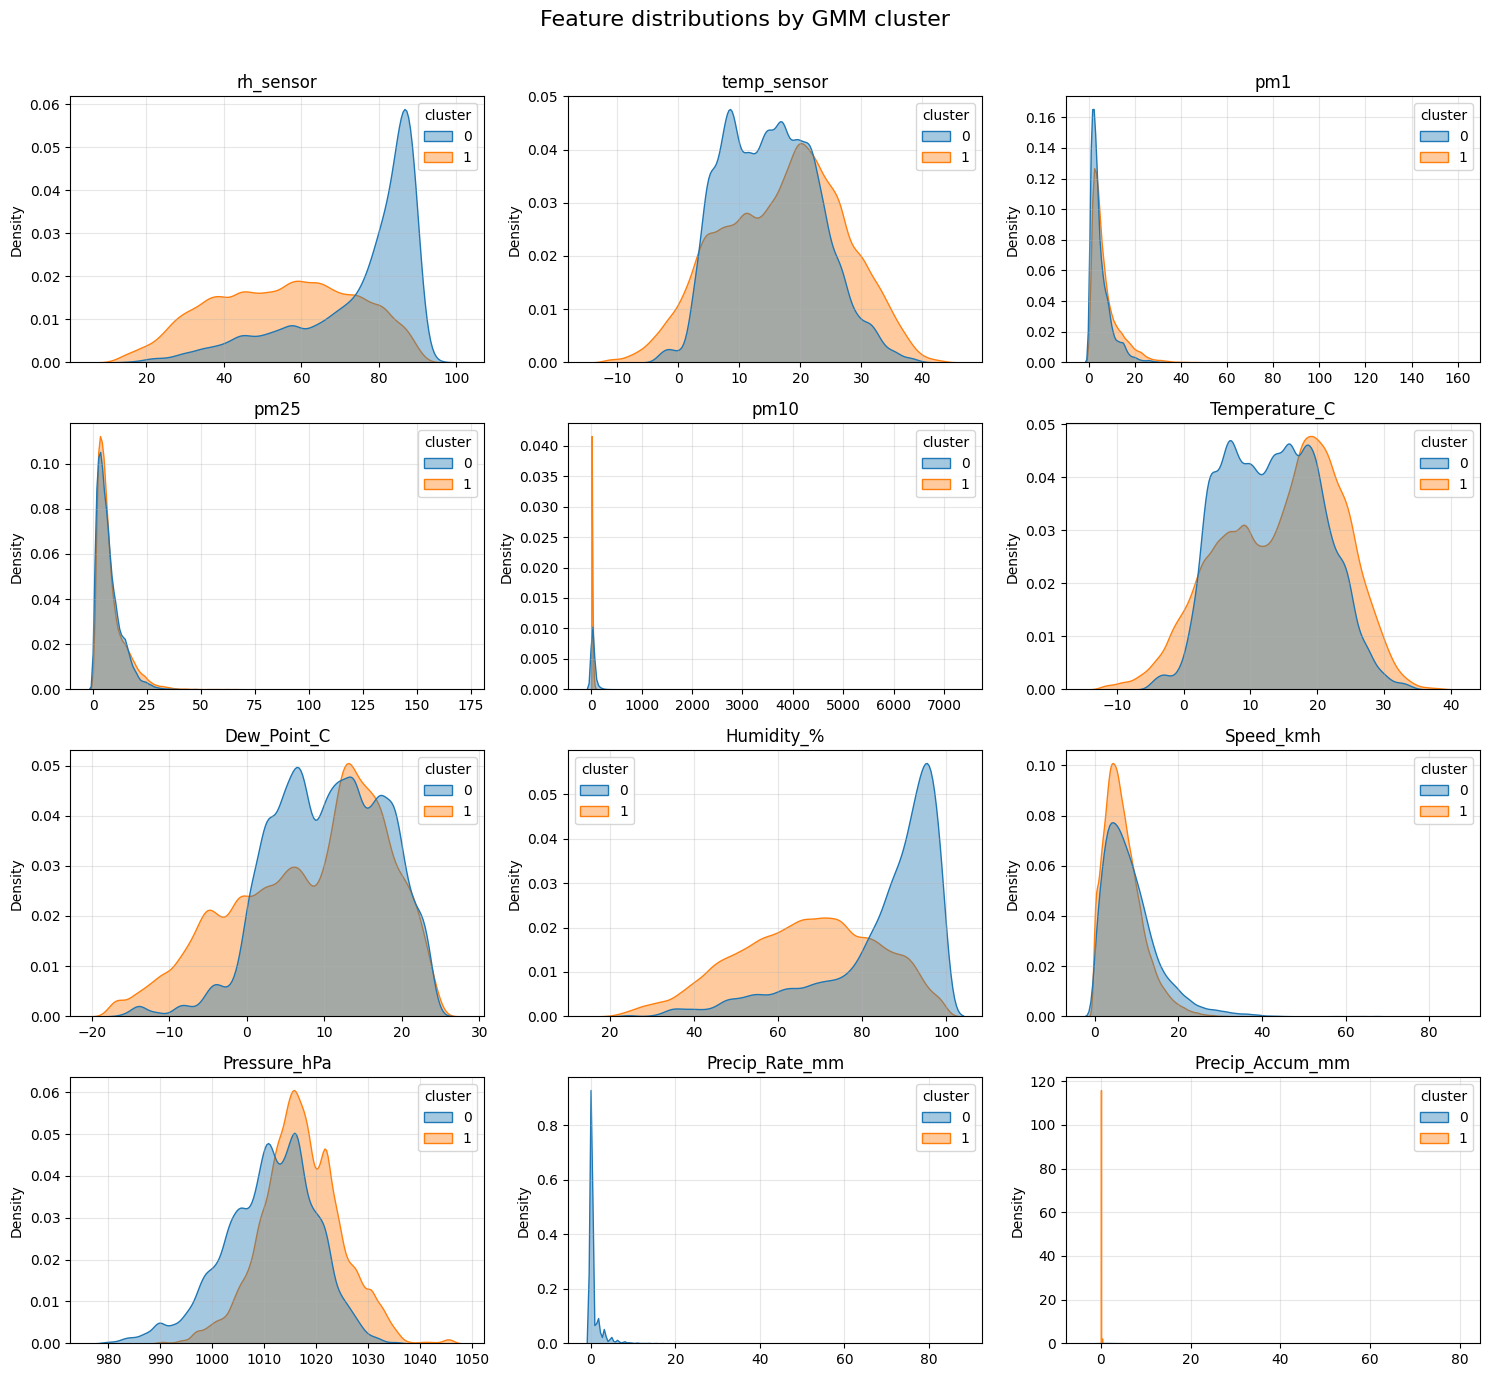

In [46]:
# DataFrame tying features to cluster labels
df_feat_vis = X_raw[feature_cols].copy()
df_feat_vis["cluster"] = clusters

n_features = len(feature_cols)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    ax = axes[i]
    sns.kdeplot(
        data=df_feat_vis,
        x=feat,
        hue="cluster",
        common_norm=False,
        fill=True,
        alpha=0.4,
        ax=ax,
    )
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.grid(True, alpha=0.3)

# Hide any unused subplots if n_features is not a multiple of n_cols
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature distributions by GMM cluster", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

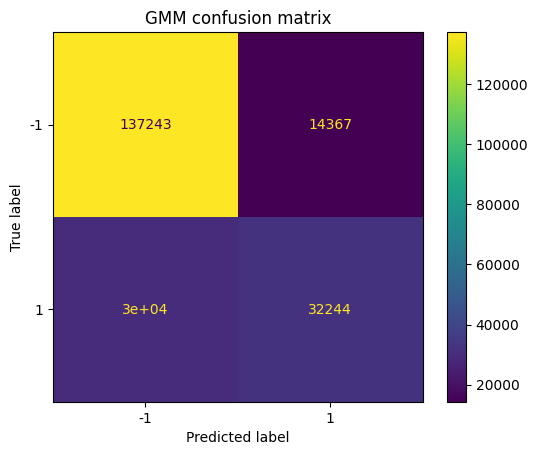

              precision    recall  f1-score   support

           0      0.820     0.905     0.861    151610
           1      0.692     0.518     0.592     62299

    accuracy                          0.792    213909
   macro avg      0.756     0.711     0.726    213909
weighted avg      0.783     0.792     0.782    213909



In [47]:
# Predicted fog / no-fog from GMM
y_pred = (clusters == fog_cluster).astype(int)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 1])
disp.plot()
plt.title(f"GMM confusion matrix")
plt.show()

print(classification_report(y, y_pred, digits=3))


### More Visualization

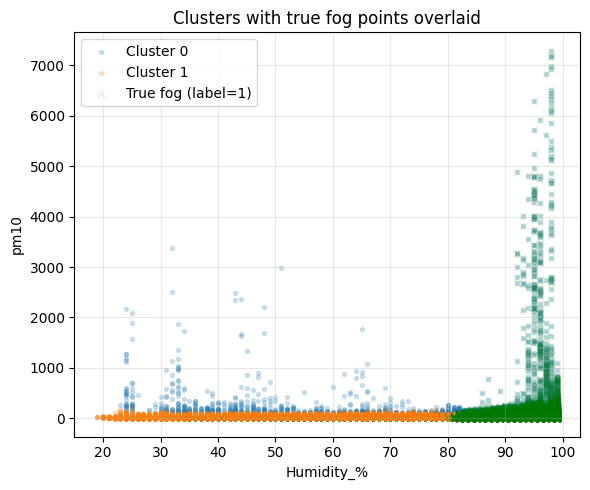

In [48]:
# Choose two features to visualize in original space
f1 = "Humidity_%"
f2 = "pm10"

x1 = X_raw[f1]
x2 = X_raw[f2]

fig, ax = plt.subplots(figsize=(6, 5))

# background: all points by cluster
for k in np.unique(clusters):
    mask = clusters == k
    ax.scatter(
        x1[mask],
        x2[mask],
        s=8,
        alpha=0.2,
        label=f"Cluster {k}"
    )

# overlay: true fog points
fog_mask = (y == 1)
ax.scatter(
    x1[fog_mask],
    x2[fog_mask],
    s=20,
    marker="x",
    color="green",
    label="True fog (label=1)",
    alpha=0.1
)

ax.set_xlabel(f1)
ax.set_ylabel(f2)
ax.set_title("Clusters with true fog points overlaid")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


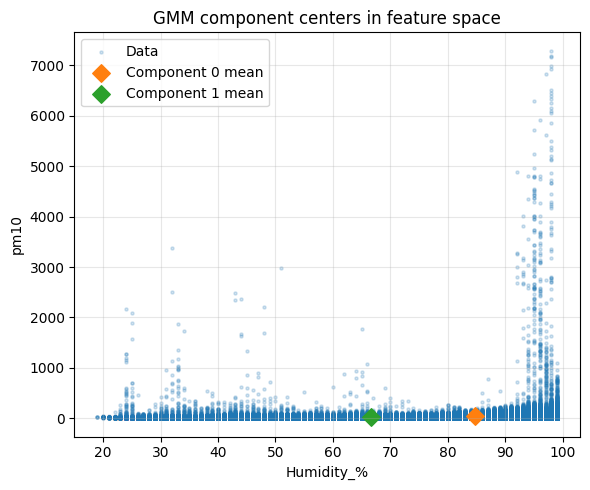

In [49]:
# Map component means from scaled space back to original feature space
means_scaled = gmm_fog.means_ # shape (n_components, n_features)
means_orig   = scaler.inverse_transform(means_scaled)

f1_idx = feature_cols.index(f1)
f2_idx = feature_cols.index(f2)

means_orig_f1 = means_orig[:, f1_idx]
means_orig_f2 = means_orig[:, f2_idx]

fig, ax = plt.subplots(figsize=(6, 5))

# data points (light background)
ax.scatter(X_raw[f1], X_raw[f2], s=5, alpha=0.2, label="Data")

# component centers
for k in range(means_orig.shape[0]):
    ax.scatter(
        means_orig_f1[k],
        means_orig_f2[k],
        s=80,
        marker="D",
        label=f"Component {k} mean"
    )

ax.set_xlabel(f1)
ax.set_ylabel(f2)
ax.set_title("GMM component centers in feature space")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


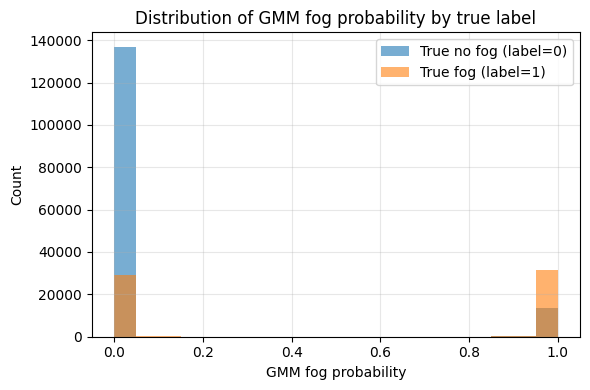

In [50]:
# GMM fog probability (probability of belonging to the fog cluster)
gmm_proba = gmm_fog.predict_proba(X)[:, fog_cluster]

fog_proba_series = pd.Series(gmm_proba, index=X_raw.index)
label_series = y  # from earlier

fig, ax = plt.subplots(figsize=(6, 4))

# non-fog
ax.hist(
    fog_proba_series[label_series == 0],
    bins=20,
    alpha=0.6,
    label="True no fog (label=0)"
)

# fog
ax.hist(
    fog_proba_series[label_series == 1],
    bins=20,
    alpha=0.6,
    label="True fog (label=1)"
)

ax.set_xlabel("GMM fog probability")
ax.set_ylabel("Count")
ax.set_title("Distribution of GMM fog probability by true label")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [51]:
import plotly.express as px

# 3D view of PM space with cluster labels
df_pm3d = X_raw[["pm1", "pm25", "pm10"]].copy()
df_pm3d["cluster"] = clusters

fig = px.scatter_3d(
    df_pm3d,
    x="pm1",
    y="pm25",
    z="pm10",
    color="cluster",
    opacity=0.6,
    title="GMM clusters in (pm1, pm25, pm10) space",
)
fig.update_traces(marker=dict(size=3))
fig.show()
